# Amazon Reviews (All_Beauty) - Exploratory Data Analysis

**Dataset:** [Amazon Reviews 2023](https://amazon-reviews-2023.github.io/) (McAuley Lab, UCSD) - `All_Beauty` category, 701,528 raw reviews across 112,590 products.

**Goal of this notebook:** understand the data well enough to make defensible modeling decisions. Specifically, three questions drive everything downstream:

1. How is rating sentiment distributed? (Determines whether we have a class-imbalance problem.)
2. How sparse is the user-item interaction matrix? (Determines whether collaborative filtering is even viable.)
3. What signals correlate with rating? (Determines which features are worth engineering.)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RAW = Path.cwd().parent / "data" / "raw"
PROCESSED = Path.cwd().parent / "data" / "processed"

## 1. Raw data scale

We load the raw reviews first (before any filtering) so the sparsity analysis reflects reality, not a pre-cleaned view.

In [2]:
raw = pd.read_json(RAW / "All_Beauty.jsonl.gz", lines=True, compression="gzip")
raw["timestamp"] = pd.to_datetime(raw["timestamp"], unit="ms")

print(f"Reviews:  {len(raw):,}")
print(f"Users:    {raw['user_id'].nunique():,}")
print(f"Products: {raw['parent_asin'].nunique():,}")
print(f"Date range: {raw['timestamp'].min():%Y-%m-%d} to {raw['timestamp'].max():%Y-%m-%d}")
raw.head(3)

Reviews:  701,528
Users:    631,986


Products: 112,565
Date range: 2000-11-01 to 2023-09-09


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True


## 2. Rating distribution - a heavily skewed target

The first thing to check on any rating dataset: are ratings balanced? (They essentially never are.)

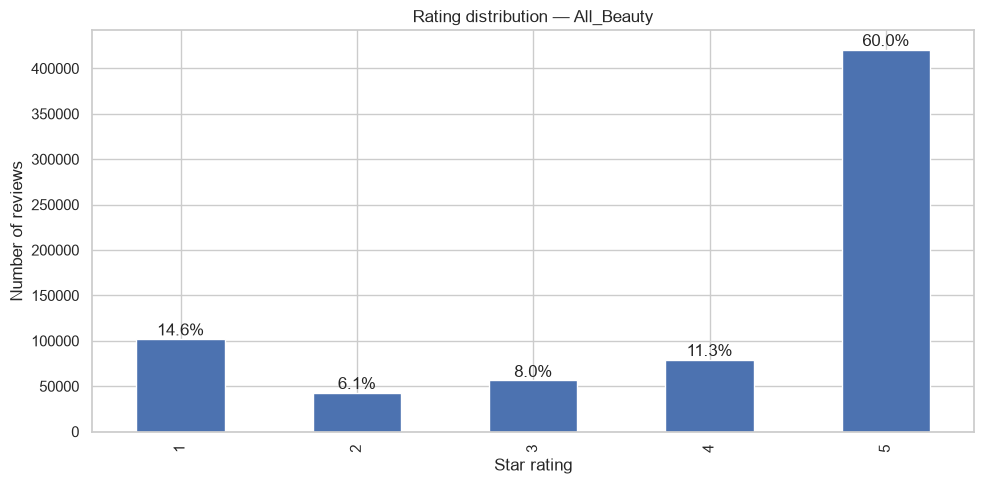

rating
1    14.6
2     6.1
3     8.0
4    11.3
5    60.0


In [3]:
rating_counts = raw["rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(raw) * 100).round(1)

ax = rating_counts.plot(kind="bar", color="#4C72B0")
ax.set_title("Rating distribution - All_Beauty")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
for i, (count, pct) in enumerate(zip(rating_counts, rating_pct)):
    ax.text(i, count, f"{pct}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(rating_pct.to_string())

**Finding:** ratings are strongly positive-skewed - roughly 3 in 5 reviews are 5-star. Two consequences for modeling:

- A sentiment classifier will look deceptively accurate if we judge it on raw accuracy alone. We need per-class precision/recall, and `class_weight="balanced"` during training.
- Predicting the mean rating is already a strong baseline for RMSE. Any rating model has to beat that, not just "look reasonable".

## 3. The sparsity problem - the single most important finding

Collaborative filtering learns from *co-occurrence*: it needs users who have rated multiple items so it can find patterns across them. So the critical question is how many reviews a typical user actually leaves.

In [4]:
user_counts = raw["user_id"].value_counts()
item_counts = raw["parent_asin"].value_counts()

print("Reviews per user")
print(f"  mean:   {user_counts.mean():.2f}")
print(f"  median: {user_counts.median():.0f}")
print(f"  users with exactly 1 review: {(user_counts == 1).sum():,} ({(user_counts == 1).mean():.1%})")
print(f"  users with >= 5 reviews:     {(user_counts >= 5).sum():,} ({(user_counts >= 5).mean():.2%})")

density = len(raw) / (raw['user_id'].nunique() * raw['parent_asin'].nunique())
print(f"\nUser-item matrix density: {density:.8%}")

Reviews per user
  mean:   1.11
  median: 1
  users with exactly 1 review: 583,553 (92.3%)
  users with >= 5 reviews:     1,620 (0.26%)



User-item matrix density: 0.00098613%


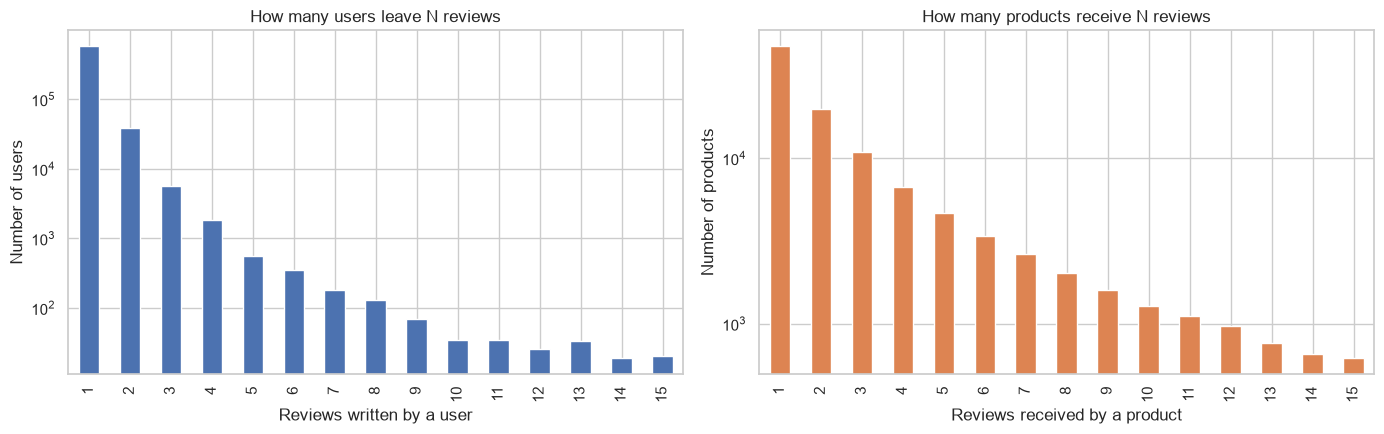

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

user_counts.value_counts().sort_index().head(15).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("How many users leave N reviews")
axes[0].set_xlabel("Reviews written by a user")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")

item_counts.value_counts().sort_index().head(15).plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("How many products receive N reviews")
axes[1].set_xlabel("Reviews received by a product")
axes[1].set_ylabel("Number of products")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Finding - this drives the entire modeling strategy:** the overwhelming majority of users have written exactly **one** review. The user-item matrix density is on the order of 0.001%.

This means:

- **Pure collaborative filtering will struggle.** A user with one interaction gives the model no co-occurrence signal to learn a preference vector from - their latent factors stay close to their random initialization.
- **We must handle cold-start explicitly**, not as an edge case. It is the *majority* case.
- **A popularity baseline is not a strawman here** - on data this sparse, "recommend what's popular" is genuinely hard to beat, and we must measure against it honestly rather than assuming a fancier model wins.

This is why the final system is a *hybrid* (collaborative + content-based + popularity) rather than pure matrix factorization.

## 4. Review volume over time

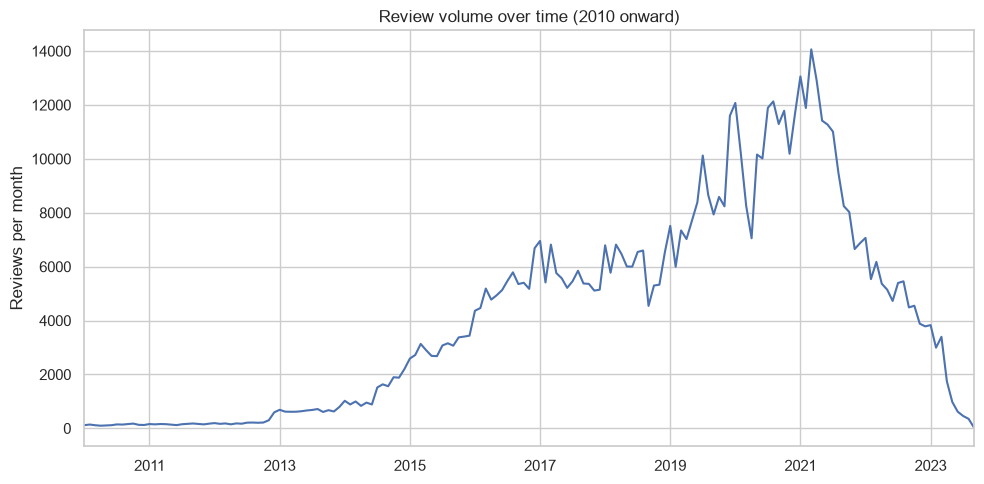

In [6]:
monthly = raw.set_index("timestamp").resample("ME").size()
monthly[monthly.index >= "2010-01-01"].plot(color="#4C72B0")
plt.title("Review volume over time (2010 onward)")
plt.ylabel("Reviews per month")
plt.xlabel("")
plt.tight_layout()
plt.show()

**Finding:** review volume grows sharply through the 2010s. Because user behaviour and the product catalogue both shift over time, a *random* train/test split would let the model train on future reviews to predict past ones - optimistic and unrealistic. We therefore use a **time-based leave-one-out split**: each user's most recent review is held out.

## 5. What correlates with rating?

This section decides which features are worth engineering for the rating model.

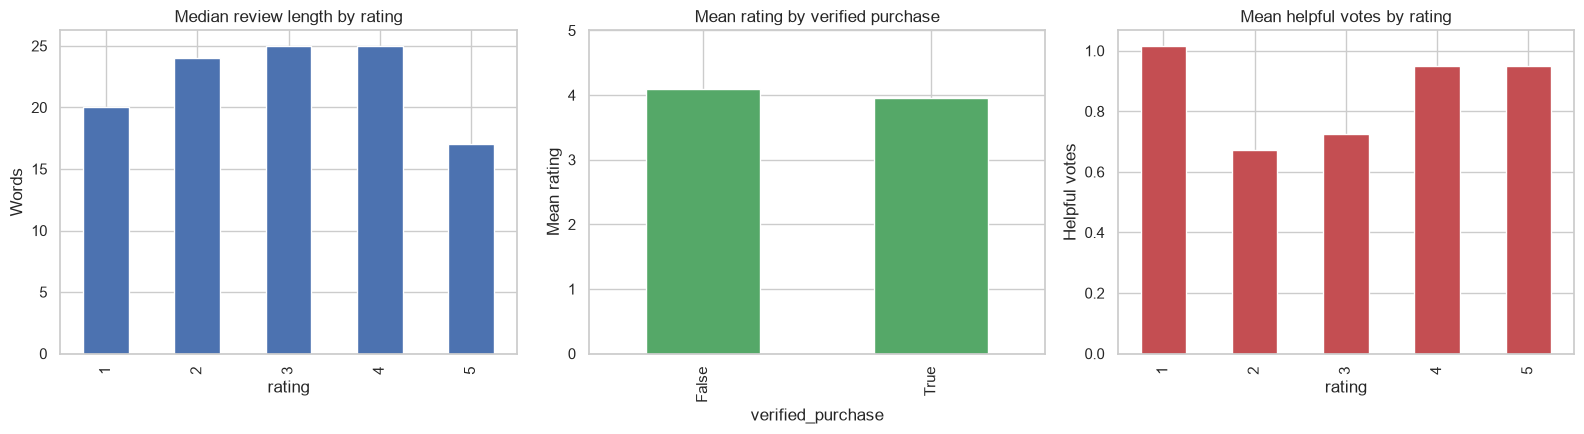

verified_purchase
False    4.086785
True     3.948535


In [7]:
sample = raw.sample(150_000, random_state=42).copy()
sample["review_length"] = sample["text"].fillna("").str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sample.groupby("rating")["review_length"].median().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Median review length by rating")
axes[0].set_ylabel("Words")

verified = sample.groupby("verified_purchase")["rating"].mean()
verified.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Mean rating by verified purchase")
axes[1].set_ylabel("Mean rating")
axes[1].set_ylim(0, 5)

sample.groupby("rating")["helpful_vote"].mean().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Mean helpful votes by rating")
axes[2].set_ylabel("Helpful votes")

plt.tight_layout()
plt.show()

print(verified.to_string())

**Findings:**

- **Negative reviews are longer.** Unhappy customers write more - dissatisfaction needs explaining, satisfaction doesn't. So `review_length` is a genuinely predictive feature, not just metadata.
- **Verified purchases rate higher on average**, so `verified_purchase` carries signal worth including.
- **Helpful votes skew toward extreme ratings** - the community engages most with strongly positive or strongly negative reviews.

These three observations are exactly the features engineered in `src/features/build_features.py`.

## 6. The modeled subset

Given the sparsity above, we filter to users with >= 2 reviews and products with >= 3 reviews. This keeps the dataset realistically long-tailed while ensuring every user has at least one training interaction and one held-out review to evaluate against.

In [8]:
reviews = pd.read_parquet(PROCESSED / "reviews.parquet")
train = pd.read_parquet(PROCESSED / "train.parquet")
test = pd.read_parquet(PROCESSED / "test.parquet")

print(f"Modeled reviews: {len(reviews):,}")
print(f"Users:           {reviews['user_id'].nunique():,}")
print(f"Products:        {reviews['parent_asin'].nunique():,}")
print(f"\nTrain: {len(train):,}   Test (1 held-out review per user): {len(test):,}")
print(f"Mean training interactions per user: {train['user_id'].value_counts().mean():.2f}")

Modeled reviews: 38,945
Users:           15,053
Products:        6,026

Train: 23,892   Test (1 held-out review per user): 15,053
Mean training interactions per user: 1.61


In [9]:
top_products = (
    reviews.groupby("product_title")
    .agg(n_reviews=("rating", "size"), mean_rating=("rating", "mean"))
    .sort_values("n_reviews", ascending=False)
    .head(10)
    .round(2)
)
top_products

,n_reviews,mean_rating
product_title,,
Salux Nylon Japanese Beauty Skin Bath Wash Cloth/towel (3) Blue Yellow and Pink,154,4.66
"Godefroy Tint Kit for Spot Coloring, Dark Brown",129,4.19
"Moroccan Argan Oil Shampoo, 8 Fl Oz - Smooths and Repairs - Sulfate Free - Natural - Imported from Morocco by Pure Body Naturals",111,4.45
Tigi Bedhead Hard Head Hairspray (6 Pack),93,4.82
"Bed Head Curve Check Curling Wand for Tousled Waves and Texture, Jumbo Barrel",90,4.08
"Retinol Face Moisturizer Cream Natural Facial moisturizing Cream 1.76 OZ with Ortho-Hydroxybenzoic Acid,VE for Hydrating,Repairing",87,4.34
"MilyBest Fluffy Lashes False Eyelashes Natural Look Cat Eye Lashes, Dramatic Faux Mink Lashes 3D Effect 18mm D Curl Volume Extension Reusable Wispy Lashes Pack 10 Pairs",81,4.51
"Dr.'s Remedy Enriched Nail Polish, Resilient Rose, 0.5 Fluid Ounce",78,4.28
Harlorki Women's Bohemian Jewelry Statement Necklaces Women Rhinestone Gem Pendant Collar,78,4.08


## Summary - what EDA told us to do

| Observation | Modeling decision |
|---|---|
| Ratings are heavily skewed to 5 stars | Use `class_weight="balanced"`; report per-class precision/recall, never bare accuracy |
| Most users have exactly 1 review; matrix density ~0.001% | Don't rely on pure CF - build a hybrid with explicit cold-start handling |
| Popularity is concentrated in a small set of products | Benchmark against a popularity baseline, and take it seriously as a competitor |
| Review volume grows sharply over time | Use a time-based leave-one-out split, not a random split |
| Negative reviews are longer; verified purchases rate higher | Engineer `review_length` and `verified_purchase` as features |

Next: `02_sentiment_and_rating_model.ipynb`.